In [1]:
# Cài Unsloth và các thư viện cần thiết
!pip install unsloth
!pip install --upgrade trl transformers accelerate datasets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 31.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 31.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 111.5 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 637.4/637.4 kB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 415.2/415.2 kB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 91.6 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 99.0 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 8.5 MB/s eta 0:00:00


# **Load model qwen3 8B**

In [3]:
from unsloth import FastLanguageModel
import torch

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name     = "unsloth/Qwen3-8B-unsloth-bnb-4bit",
    max_seq_length = 2048,
    load_in_4bit   = True,
    load_in_8bit   = False,
    full_finetuning = False,
)
print("Load model xong")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.2: Fast Qwen3 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/399 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/237 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

unsloth/Qwen3-8B-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
Load model xong


In [4]:
model = FastLanguageModel.get_peft_model(
    model,
    r                        = 16,
    target_modules           = ["q_proj", "k_proj", "v_proj", "o_proj",
                                "gate_proj", "up_proj", "down_proj"],
    lora_alpha               = 32,    # alpha = 2*rank
    lora_dropout             = 0,
    bias                     = "none",
    use_gradient_checkpointing = "unsloth",
    random_state             = 3407,
    use_rslora               = False,
    loftq_config             = None,
)
print("Lora adapter sẵn sàng")
print(f"  Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Unsloth 2026.4.2 patched 36 layers with 36 QKV layers, 36 O layers and 36 MLP layers.


Lora adapter sẵn sàng
  Trainable params: 43,646,976


In [5]:
import json
from datasets import Dataset

TRAIN_PATH = "/kaggle/input/datasets/thangdeovan/data-f/haui_qa_train_final.jsonl"
VAL_PATH   = "/kaggle/input/datasets/thangdeovan/data-f/haui_qa_val_final.jsonl"

def load_jsonl(path):
    data = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                data.append(json.loads(line))
    return data

train_raw = load_jsonl(TRAIN_PATH)
val_raw   = load_jsonl(VAL_PATH)

print(f"Train: {len(train_raw)} mẫu")
print(f"Val  : {len(val_raw)} mẫu")
print()
print("Mẫu đầu tiên:")
print(f"  Q: {train_raw[0]['instruction']}")
print(f"  A: {train_raw[0]['output'][:80]}...")

Train: 380 mẫu
Val  : 95 mẫu

Mẫu đầu tiên:
  Q: Em quan tâm đến ngành Kỹ thuật sản xuất thông minh, vậy mã xét tuyển của ngành này là gì ạ?
  A: Chào bạn! Ngành Kỹ thuật sản xuất thông minh tại Trường Đại học Công nghiệp Hà N...


In [6]:
def format_to_chat(sample):
    """Chuyển 1 bản ghi JSONL thành chat text mà Qwen3 hiểu."""
    messages = [
        {"role": "system",    "content": sample["system"]},
        {"role": "user",      "content": sample["instruction"]},
        {"role": "assistant", "content": sample["output"]},
    ]
    # apply_chat_template thêm <|im_start|>, <|im_end|> đúng chuẩn Qwen3
    text = tokenizer.apply_chat_template(
        messages,
        tokenize        = False,
        add_generation_prompt = False,
    )
    return {"text": text}

# Format toàn bộ dataset
train_formatted = [format_to_chat(s) for s in train_raw]
val_formatted   = [format_to_chat(s) for s in val_raw]

train_dataset = Dataset.from_list(train_formatted)
val_dataset   = Dataset.from_list(val_formatted)

print(f"Train dataset: {len(train_dataset)} mẫu")
print(f"Val dataset  : {len(val_dataset)} mẫu")
print()
print("Ví dụ 1 mẫu đã format:")
print(train_dataset[0]["text"][:300])

Train dataset: 380 mẫu
Val dataset  : 95 mẫu

Ví dụ 1 mẫu đã format:
<|im_start|>system
Bạn là trợ lý tư vấn tuyển sinh của Đại học Công nghiệp Hà Nội (HAUI). Hãy trả lời chính xác, thân thiện và ngắn gọn dựa trên thông tin tuyển sinh của trường.<|im_end|>
<|im_start|>user
Em quan tâm đến ngành Kỹ thuật sản xuất thông minh, vậy mã xét tuyển của ngành này là gì ạ?<|im


In [13]:
from trl import SFTTrainer, SFTConfig
from unsloth import is_bfloat16_supported

trainer = SFTTrainer(
    model         = model,
    tokenizer     = tokenizer,
    train_dataset = train_dataset,
    eval_dataset  = val_dataset,
    dataset_text_field = "text",
    max_seq_length     = 2048,
    dataset_num_proc   = 2, 
    args = SFTConfig(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 8,
        warmup_steps               = 10,
        num_train_epochs           = 3, 
        learning_rate              = 2e-4,
        fp16                       = not is_bfloat16_supported(),
        bf16                       = is_bfloat16_supported(),
        logging_steps              = 1,
        eval_strategy              = "steps",
        padding_free=False,
        eval_steps                 = 20, # Đánh giá thường xuyên hơn để vẽ biểu đồ
        save_strategy              = "steps",
        save_steps                 = 20,
        load_best_model_at_end     = True,
        metric_for_best_model      = "eval_loss",
        optim                      = "adamw_8bit",
        weight_decay               = 0.01,
        lr_scheduler_type          = "cosine",
        seed                       = 3407,
        output_dir                 = "/kaggle/working/qwen3_haui_checkpoints",
        report_to                  = "none", 
    ),
)
print("✓ Trainer sẵn sàng")

Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/380 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/95 [00:00<?, ? examples/s]

✓ Trainer sẵn sàng


In [14]:
trainer_stats = trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 380 | Num Epochs = 3 | Total steps = 72
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 8 x 1) = 16
 "-____-"     Trainable parameters = 43,646,976 of 8,234,382,336 (0.53% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,Validation Loss
20,0.887706,0.747363
40,0.506223,0.544042
60,0.501359,0.496884
72,0.392491,0.491449


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:172: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API 

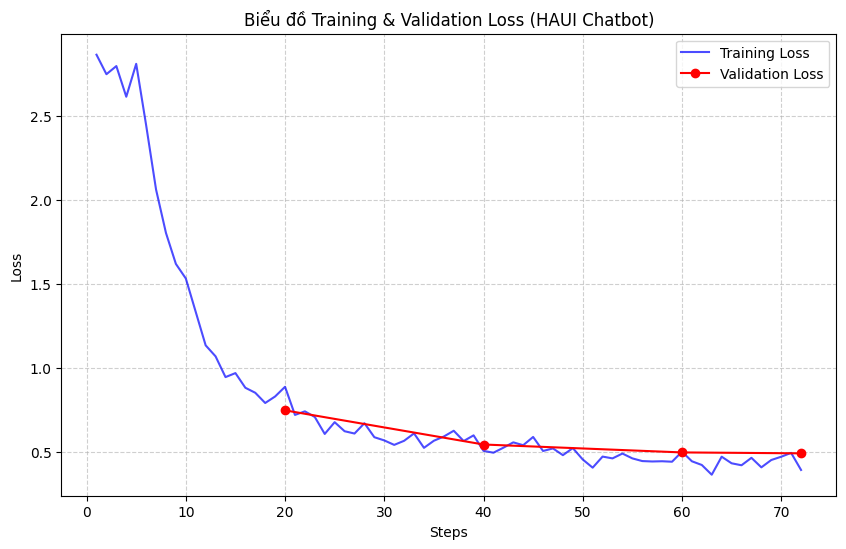

In [15]:
import matplotlib.pyplot as plt

def plot_loss(trainer):
    history = trainer.state.log_history
    
    train_loss = [x['loss'] for x in history if 'loss' in x]
    train_steps = [x['step'] for x in history if 'loss' in x]
    
    val_loss = [x['eval_loss'] for x in history if 'eval_loss' in x]
    val_steps = [x['step'] for x in history if 'eval_loss' in x]

    plt.figure(figsize=(10, 6))
    plt.plot(train_steps, train_loss, label='Training Loss', color='blue', alpha=0.7)
    if val_loss:
        plt.plot(val_steps, val_loss, label='Validation Loss', color='red', marker='o')
    
    plt.title('Biểu đồ Training & Validation Loss (HAUI Chatbot)')
    plt.xlabel('Steps')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # Lưu ảnh để đưa vào báo cáo
    plt.savefig('loss_curve.png', dpi=300)
    plt.show()

# Gọi hàm sau khi train xong
plot_loss(trainer)

In [19]:
# Chuyển sang inference mode
FastLanguageModel.for_inference(model)

def chat(question, max_new_tokens=256):
    messages = [
        {"role": "system",  "content": "Bạn là trợ lý tư vấn tuyển sinh của Đại học Công nghiệp Hà Nội (HAUI). Hãy trả lời chính xác, thân thiện và ngắn gọn dựa trên thông tin tuyển sinh của trường."},
        {"role": "user",    "content": question},
    ]
    text = tokenizer.apply_chat_template(
        messages,
        tokenize              = False,
        add_generation_prompt = True,
        enable_thinking       = False,  # Tắt reasoning mode
    )
    inputs = tokenizer(text, return_tensors="pt").to("cuda")
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens = max_new_tokens,
            max_length = None,
            temperature    = 0.7,
            top_p          = 0.9,
            do_sample      = True,
            pad_token_id   = tokenizer.eos_token_id,
        )
    result = tokenizer.decode(outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    return result.strip()

# Test với một số câu hỏi
test_questions = [
    "HAUI tuyển sinh theo những phương thức nào năm 2026?",
    "Điểm chuẩn ngành Công nghệ thông tin HAUI năm 2024 là bao nhiêu?",
    "Ngành Ngôn ngữ Anh xét tuyển tổ hợp môn gì?",
]

for q in test_questions:
    print(f"Q: {q}")
    print(f"A: {chat(q)}")
    print()

Q: HAUI tuyển sinh theo những phương thức nào năm 2026?
A: Chào bạn, Trường Đại học Công nghiệp Hà Nội sẽ tuyển sinh theo các phương thức sau: Phương thức 1, Phương thức 2, Phương thức 3, và Phương thức 5. Các phương thức này đều áp dụng cho các chương trình đào tạo từ bậc Đại học chính quy.

Q: Điểm chuẩn ngành Công nghệ thông tin HAUI năm 2024 là bao nhiêu?
A: Chào bạn, đối với ngành Công nghệ thông tin (mã ngành 7480101) của Trường Đại học Công nghiệp Hà Nội năm 2024, điểm chuẩn trúng tuyển là 25.80.

Q: Ngành Ngôn ngữ Anh xét tuyển tổ hợp môn gì?
A: Chào bạn, ngành Ngôn ngữ Anh (mã 7220201) xét tuyển các tổ hợp môn D01, D04, D14 nhé.



In [20]:

# !pip install evaluate rouge_score

import evaluate
import pandas as pd

rouge = evaluate.load("rouge")

def calculate_metrics(test_samples):
    predictions = []
    references = []
    
    print("Đang tính toán ROUGE Score...")
    for sample in test_samples:
        q = sample['instruction']
        ref = sample['output']
        pred = chat(q) # Hàm chat bạn đã viết ở cell trước
        
        predictions.append(pred)
        references.append(ref)
    
    results = rouge.compute(predictions=predictions, references=references)
    return results

# Chạy thử trên 20 mẫu tập Val để lấy số liệu vào báo cáo
metrics_results = calculate_metrics(val_raw[:20])
print("\nKết quả độ đo ROUGE cho báo cáo:")
print(pd.Series(metrics_results))

Đang tính toán ROUGE Score...

Kết quả độ đo ROUGE cho báo cáo:
rouge1       0.690714
rouge2       0.504212
rougeL       0.554036
rougeLsum    0.570690
dtype: float64


In [22]:
import evaluate
import numpy as np

# Load metric BLEU
bleu = evaluate.load("bleu")

def calculate_bleu(test_samples):
    predictions = []
    references = [] 
    
    print("Đang tính toán BLEU Score...")
    # SỬA LỖI CHÍNH Ở ĐÂY: Dùng biến test_samples được truyền vào hàm
    for sample in test_samples[:50]: # Chạy thử trên 50 mẫu để tiết kiệm thời gian
        q = sample['instruction']
        ref = sample['output']
        pred = chat(q) 
        
        predictions.append(pred)
        references.append([ref]) # BLEU yêu cầu mảng 2 chiều cho references
    
    results = bleu.compute(predictions=predictions, references=references)
    return results

# Truyền đúng tập val_raw của bạn vào để test
bleu_results = calculate_bleu(val_raw)
print(f"BLEU Score: {bleu_results['bleu']:.4f}")

Đang tính toán BLEU Score...
BLEU Score: 0.3207


In [23]:
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

# Load model embedding chuyên cho tiếng Việt
embed_model = SentenceTransformer('keepitreal/vietnamese-sbert')

def calculate_semantic_similarity(test_samples):
    similarities = []
    
    print("Đang tính toán Semantic Similarity...")
    for sample in test_samples[:30]: # Test thử 30 mẫu
        ref = sample['output']
        pred = chat(sample['instruction'])
        
        # Biến câu thành vector
        embeddings = embed_model.encode([ref, pred])
        
        # Tính Cosine Similarity
        score = cosine_similarity([embeddings[0]], [embeddings[1]])[0][0]
        similarities.append(score)
    
    avg_score = sum(similarities) / len(similarities)
    return avg_score

# Chạy và in kết quả
avg_semantic_sim = calculate_semantic_similarity(val_raw)
print(f"Average Semantic Similarity: {avg_semantic_sim:.4f}")

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/752 [00:00<?, ?B/s]

...

bpe.codes: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Đang tính toán Semantic Similarity...


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API i

Average Semantic Similarity: 0.7921


In [24]:
SAVE_PATH = "/kaggle/working/qwen3_haui_lora"
model.save_pretrained(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)
print(f"Đã lưu LoRA adapter → {SAVE_PATH}")

# Xem kích thước
import os
total_size = sum(
    os.path.getsize(os.path.join(SAVE_PATH, f))
    for f in os.listdir(SAVE_PATH)
) / 1024 / 1024
print(f"  Kích thước: {total_size:.1f} MB")
print()
print("Files trong thư mục:")
for f in sorted(os.listdir(SAVE_PATH)):
    sz = os.path.getsize(os.path.join(SAVE_PATH, f)) / 1024 / 1024
    print(f"  {f:<40} {sz:.1f} MB")

Đã lưu LoRA adapter → /kaggle/working/qwen3_haui_lora
  Kích thước: 177.5 MB

Files trong thư mục:
  README.md                                0.0 MB
  adapter_config.json                      0.0 MB
  adapter_model.safetensors                166.6 MB
  chat_template.jinja                      0.0 MB
  tokenizer.json                           10.9 MB
  tokenizer_config.json                    0.0 MB


In [25]:
# Zip toàn bộ adapter để download 1 file
!zip -r /kaggle/working/qwen3_haui_lora.zip /kaggle/working/qwen3_haui_lora/

import os
zip_size = os.path.getsize("/kaggle/working/qwen3_haui_lora.zip") / 1024 / 1024
print(f"✓ File zip: qwen3_haui_lora.zip ({zip_size:.1f} MB)")
print()
print("Vào tab Output bên phải Kaggle → Download file qwen3_haui_lora.zip")

  adding: kaggle/working/qwen3_haui_lora/ (stored 0%)
  adding: kaggle/working/qwen3_haui_lora/chat_template.jinja (deflated 76%)
  adding: kaggle/working/qwen3_haui_lora/README.md (deflated 65%)
  adding: kaggle/working/qwen3_haui_lora/adapter_config.json (deflated 58%)
  adding: kaggle/working/qwen3_haui_lora/tokenizer.json (deflated 81%)
  adding: kaggle/working/qwen3_haui_lora/tokenizer_config.json (deflated 43%)
  adding: kaggle/working/qwen3_haui_lora/adapter_model.safetensors (deflated 7%)
✓ File zip: qwen3_haui_lora.zip (156.2 MB)

Vào tab Output bên phải Kaggle → Download file qwen3_haui_lora.zip
